In [4]:
#%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
delta_time = 24*30
probas_dayglow = pd.DataFrame()
probas_nightglow = pd.DataFrame()
probas_dayglow_highproc = pd.DataFrame()
probas_nightglow_highproc = pd.DataFrame()

use_brune = False
scenario = 'active_low_max'
snrs = [1., 75.]

## Files generated above when computing map with airglow
files_to_load = []
for freq in [0.01, 0.1, 1.]:

    debug = '_test'
    #if freq < 1:
    #    debug = '_test'
    
    #probas_dayglow_SNRnight1.0_SNRday1_same_event_mHot40_new_1.0Hz_bruneFalse.csv
    #probas_dayglow_SNRnight75.0_SNRday75.0_same_event_mHot40_06.12.2025_1.0Hz_bruneFalse_active_high_min_08.12.2025.csv
    file = f'../data/final_probas/probas_dayglow_SNRnight{snrs[0]}_SNRday{snrs[0]}_same_event_mCold100_20.12.2025_{freq}Hz_brune{use_brune}_{scenario}_20.12.2025{debug}.csv'
    files_to_load.append( file )
    probas_dayglow_loc = pd.read_csv(file, header=[0])
    probas_dayglow_loc['freq'] = freq
    
    file = f'../data/final_probas/probas_nightglow_SNRnight{snrs[0]}_SNRday{snrs[0]}_same_event_mCold100_20.12.2025_{freq}Hz_brune{use_brune}_{scenario}_20.12.2025{debug}.csv'
    files_to_load.append( file )
    probas_nightglow_loc = pd.read_csv(file, header=[0])
    probas_nightglow_loc['freq'] = freq
    
    probas_dayglow_loc = probas_dayglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)
    probas_nightglow_loc = probas_nightglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)

    probas_dayglow = pd.concat([probas_dayglow, probas_dayglow_loc])
    probas_nightglow = pd.concat([probas_nightglow, probas_nightglow_loc])
    
    ##########
    #probas_dayglow_SNRnight1.0_SNRday1_same_event_mHot40_new_1.0Hz_bruneFalse.csv
    file = f'../data/final_probas/probas_dayglow_SNRnight{snrs[1]}_SNRday{snrs[1]}_same_event_mCold100_20.12.2025_{freq}Hz_brune{use_brune}_{scenario}_20.12.2025{debug}.csv'
    files_to_load.append( file )
    probas_dayglow_loc = pd.read_csv(file, header=[0])
    probas_dayglow_loc['freq'] = freq
    
    file = f'../data/final_probas/probas_nightglow_SNRnight{snrs[1]}_SNRday{snrs[1]}_same_event_mCold100_20.12.2025_{freq}Hz_brune{use_brune}_{scenario}_20.12.2025{debug}.csv'
    files_to_load.append( file )
    probas_nightglow_loc = pd.read_csv(file, header=[0])
    probas_nightglow_loc['freq'] = freq
    
    probas_dayglow_loc = probas_dayglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)
    probas_nightglow_loc = probas_nightglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)

    probas_dayglow_highproc = pd.concat([probas_dayglow_highproc, probas_dayglow_loc])
    probas_nightglow_highproc = pd.concat([probas_nightglow_highproc, probas_nightglow_loc])

print(files_to_load)
    
def probas_airglow_func(day, snrs, probas_airglow):

    probas_hours = probas_airglow.hour.values
    probas_snrs = probas_airglow.SNR.values
    proba_idx = np.arange(probas_hours.size)
    requested_idx = np.arange(day.size)
    
    m_proba_idx, m_requested_idx = np.meshgrid(proba_idx, requested_idx)
    shape_m_idx = m_proba_idx.shape
    m_proba_idx, m_requested_idx = m_proba_idx.ravel(), m_requested_idx.ravel()
    
    idx_okay = abs(probas_hours[m_proba_idx]-day[m_requested_idx]*24).reshape(shape_m_idx)
    idx_okay += abs(probas_snrs[m_proba_idx]-snrs[m_requested_idx]).reshape(shape_m_idx)
    idx_okay = m_proba_idx[idx_okay.argmin(axis=1)]
    #print(probas_airglow.hour.values[idx_okay])
    #print(probas_airglow.SNR.values[idx_okay])
    #idx_okay_day = np.argmin(abs(probas_snrs[m_proba_idx]-snrs[m_requested_idx]))
    #idx_okay = (abs(probas_hours[m_proba_idx]-day[m_requested_idx]*24) < threshold_hour) & (abs(probas_snrs[m_proba_idx]-snrs[m_requested_idx]) < threshold_snr)
    #idx_okay = m_proba_idx[idx_okay]
    
    return probas_airglow.proba.values[idx_okay]

day = np.arange(30, 30*6, 30)
snrs = np.zeros_like(day)+1
probas_airglow_func(day, snrs, probas_nightglow)

/tmp/ipykernel_1675093/1937793238.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  probas_dayglow_loc = probas_dayglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)
/tmp/ipykernel_1675093/1937793238.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  probas_nightglow_loc = probas_nightglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).r

['../data/final_probas/probas_dayglow_SNRnight1.0_SNRday1.0_same_event_mCold100_20.12.2025_0.01Hz_bruneFalse_active_low_max_20.12.2025_test.csv', '../data/final_probas/probas_nightglow_SNRnight1.0_SNRday1.0_same_event_mCold100_20.12.2025_0.01Hz_bruneFalse_active_low_max_20.12.2025_test.csv', '../data/final_probas/probas_dayglow_SNRnight75.0_SNRday75.0_same_event_mCold100_20.12.2025_0.01Hz_bruneFalse_active_low_max_20.12.2025_test.csv', '../data/final_probas/probas_nightglow_SNRnight75.0_SNRday75.0_same_event_mCold100_20.12.2025_0.01Hz_bruneFalse_active_low_max_20.12.2025_test.csv', '../data/final_probas/probas_dayglow_SNRnight1.0_SNRday1.0_same_event_mCold100_20.12.2025_0.1Hz_bruneFalse_active_low_max_20.12.2025_test.csv', '../data/final_probas/probas_nightglow_SNRnight1.0_SNRday1.0_same_event_mCold100_20.12.2025_0.1Hz_bruneFalse_active_low_max_20.12.2025_test.csv', '../data/final_probas/probas_dayglow_SNRnight75.0_SNRday75.0_same_event_mCold100_20.12.2025_0.1Hz_bruneFalse_active_low_m

/tmp/ipykernel_1675093/1937793238.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  probas_dayglow_loc = probas_dayglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)
/tmp/ipykernel_1675093/1937793238.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  probas_nightglow_loc = probas_nightglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).r

array([0., 0., 0., 0., 0.])

In [14]:
from tqdm import tqdm

def filter_snrs(pd_final_probas_loc, snrs_selected):
    snr_available = pd_final_probas_loc.loc[:,'snr'].unique()
    snr_available = [snr_available[np.argmin(abs(snr-snr_available))] for snr in snrs_selected]
    pd_final_probas_loc = pd_final_probas_loc.loc[pd_final_probas_loc.snr.isin(snr_available)]
    return pd_final_probas_loc

pd_final_probas = pd.DataFrame()
pd_final_probas_airglow = pd.DataFrame()

dir_probas = '../data/final_probas/'

snrs_selected = [1., 2., 5.]

scenario = 'active_low_max'
#alts = [45, 55, 65]
alts = [50., 55., 60., 65.]

vel_models = ['Cold100', 'Hot40', 'Hot25', 'Hot10']
vel_model_highlight = 'Cold100'

periods = [1, 10, 100]

files_to_load = []
for alt in tqdm(alts):
    for period in periods:
        for vel_model in vel_models:

            ## comparison between balloon configurations
            sensor_type = 'one_balloon_same_event'
            file = f'{dir_probas}final_probas_{sensor_type}_{scenario}_n0.01_alt{alt:.0f}_{period}s_{vel_model}_24.10.2025.csv'
            pd_final_probas_loc = pd.read_csv(file)
            files_to_load.append( file )
            pd_final_probas_loc = filter_snrs(pd_final_probas_loc, snrs_selected)
            pd_final_probas_loc['seismicity'] = '1 balloon'
            pd_final_probas_loc['fmax'] = 1./period
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas = pd.concat([pd_final_probas, pd_final_probas_loc])

            sensor_type = 'network_same_event'
            file = f'{dir_probas}final_probas_{sensor_type}_{scenario}_n0.01_alt{alt:.0f}_{period}s_{vel_model}_24.10.2025.csv'
            pd_final_probas_loc = pd.read_csv(file)
            files_to_load.append( file )
            pd_final_probas_loc = filter_snrs(pd_final_probas_loc, snrs_selected)
            pd_final_probas_loc['seismicity'] = 'same event'
            pd_final_probas_loc['fmax'] = 1./period
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas = pd.concat([pd_final_probas, pd_final_probas_loc])
            pd_final_probas_balloons = pd_final_probas_loc.copy()

            sensor_type = 'network_any_event'
            file = f'{dir_probas}final_probas_{sensor_type}_{scenario}_n0.01_alt{alt:.0f}_{period}s_{vel_model}_15.11.2025.csv'
            pd_final_probas_loc = pd.read_csv(file)
            files_to_load.append( file )
            pd_final_probas_loc = filter_snrs(pd_final_probas_loc, snrs_selected)
            pd_final_probas_loc['seismicity'] = 'any event'
            pd_final_probas_loc['fmax'] = 1./period
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas = pd.concat([pd_final_probas, pd_final_probas_loc])

            ## comparison between airglow and balloons
            if not vel_model == vel_model_highlight:
                continue
                
            pd_final_probas_loc = pd_final_probas_balloons.copy()
            probas_nightglow_loc = probas_nightglow.loc[probas_nightglow.freq==1./period]
            days = pd_final_probas_loc.loc[:, 'duration'].values
           # days[days==days.max()] = 30*24
            pd_final_probas_loc.loc[:, 'proba'] = probas_airglow_func(days, pd_final_probas_loc.loc[:, 'snr'].values, probas_nightglow_loc)
            pd_final_probas_loc['seismicity'] = 'nightglow'
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas_loc['duration'] = days
            pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_loc])

            pd_final_probas_loc = pd_final_probas_balloons.copy()
            probas_dayglow_loc = probas_dayglow.loc[probas_dayglow.freq==1./period]
            days = pd_final_probas_loc.loc[:, 'duration'].values
            #days[days==days.max()] = 30*24
            pd_final_probas_loc.loc[:, 'proba'] = probas_airglow_func(days, pd_final_probas_loc.loc[:, 'snr'].values, probas_dayglow_loc)
            pd_final_probas_loc['seismicity'] = 'dayglow'
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas_loc['duration'] = days
            pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_loc])
            
            pd_final_probas_loc = pd_final_probas_balloons.copy()
            probas_nightglow_loc = probas_nightglow_highproc.loc[probas_nightglow_highproc.freq==1./period]
            days = pd_final_probas_loc.loc[:, 'duration'].values
            #days[days==days.max()] = 30*24
            pd_final_probas_loc.loc[:, 'proba'] = probas_airglow_func(days, pd_final_probas_loc.loc[:, 'snr'].values, probas_nightglow_loc)
            pd_final_probas_loc['seismicity'] = 'nightglow - proc'
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas_loc['duration'] = days
            pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_loc])

            pd_final_probas_loc = pd_final_probas_balloons.copy()
            probas_dayglow_loc = probas_dayglow_highproc.loc[probas_dayglow_highproc.freq==1./period]
            days = pd_final_probas_loc.loc[:, 'duration'].values
            #days[days==days.max()] = 30*24
            pd_final_probas_loc.loc[:, 'proba'] = probas_airglow_func(days, pd_final_probas_loc.loc[:, 'snr'].values, probas_dayglow_loc)
            pd_final_probas_loc['seismicity'] = 'dayglow - proc'
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas_loc['duration'] = days
            pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_loc])

            #pd_final_probas_balloons['seismicity'] = 'balloons'
            #pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_balloons])

print(files_to_load)

100%|██████████| 4/4 [01:13<00:00, 18.41s/it]

['../data/final_probas/final_probas_one_balloon_same_event_active_low_max_n0.01_alt50_1s_Cold100_24.10.2025.csv', '../data/final_probas/final_probas_network_same_event_active_low_max_n0.01_alt50_1s_Cold100_24.10.2025.csv', '../data/final_probas/final_probas_network_any_event_active_low_max_n0.01_alt50_1s_Cold100_15.11.2025.csv', '../data/final_probas/final_probas_one_balloon_same_event_active_low_max_n0.01_alt50_1s_Hot40_24.10.2025.csv', '../data/final_probas/final_probas_network_same_event_active_low_max_n0.01_alt50_1s_Hot40_24.10.2025.csv', '../data/final_probas/final_probas_network_any_event_active_low_max_n0.01_alt50_1s_Hot40_15.11.2025.csv', '../data/final_probas/final_probas_one_balloon_same_event_active_low_max_n0.01_alt50_1s_Hot25_24.10.2025.csv', '../data/final_probas/final_probas_network_same_event_active_low_max_n0.01_alt50_1s_Hot25_24.10.2025.csv', '../data/final_probas/final_probas_network_any_event_active_low_max_n0.01_alt50_1s_Hot25_15.11.2025.csv', '../data/final_probas

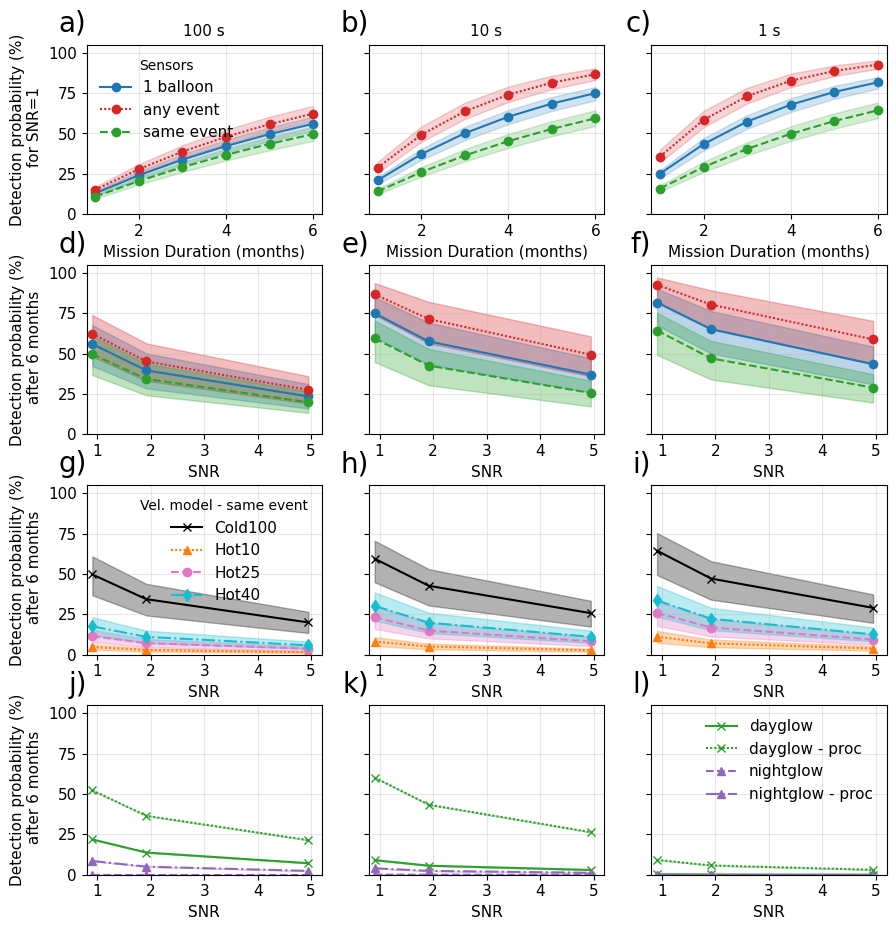

In [5]:
import string

def plot_proba_vs_duration(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, SNR_legend, seismicity_legend, fontsize_label, colors, ls, markers, color_labels, title_legend):
    
    snr_handles = []  # Handles for SNR legend
    seismicity_handles = []  # Handles for Seismicity legend

    for iseismicity, (seismicity, pd_final_probas_seismicity) in enumerate(pd_final_probas_fmax.groupby('seismicity')):

        for isnr, (snr, pd_final_probas_snr) in enumerate(pd_final_probas_seismicity.groupby('snr')):

            if snr in snr_to_exclude:
                continue

            duration = pd_final_probas_snr.duration.unique()
            probas = pd_final_probas_snr.groupby(['duration']).proba.median().reset_index().proba.values*1e2
            #qmin_probas = pd_final_probas_snr.groupby(['duration']).proba.min().reset_index().proba.values*1e2
            #qmax_probas = pd_final_probas_snr.groupby(['duration']).proba.max().reset_index().proba.values*1e2
            qmin_probas = pd_final_probas_snr.groupby(['duration']).proba.quantile(q=0.3).reset_index().proba.values*1e2
            qmax_probas = pd_final_probas_snr.groupby(['duration']).proba.quantile(q=0.7).reset_index().proba.values*1e2

            label_dict = dict()
            if iseismicity == 0 and ifmax == 0:
                snr_label = f'{snr:.0f}'
                label_dict = dict(label=snr_label)
                snr_handles.append(ax.plot([], [], marker=markers[iseismicity], color=colors[iseismicity], label=snr_label)[0])

            if ifmax == 0 and isnr == 0:
                seismicity_label = f'{seismicity}'
                seismicity_handles.append(ax.plot([], [], color=colors[iseismicity], marker=markers[iseismicity], label=seismicity_label, ls=ls[iseismicity])[0])

            ax.plot(duration/30., probas, marker=markers[iseismicity], color=colors[iseismicity], ls=ls[iseismicity], **label_dict)
            ax.fill_between(duration/30., qmin_probas, qmax_probas, color=colors[iseismicity], alpha=0.2)

    ax.tick_params(axis='both', colors=color_labels, labelsize=fontsize_label)
    if ifmax == 0 and SNR_legend:
        legend1 = ax.legend(handles=snr_handles, frameon=False, title='SNR', fontsize=fontsize_label, loc='upper right',)
        ax.add_artist(legend1)  # Add the first legend to the axis

    if ifmax == 0 and seismicity_legend:
        # Add the second legend for Seismicity
        ax.legend(handles=seismicity_handles, frameon=False,  title='Sensors', fontsize=fontsize_label, loc='upper left')
        #ax.legend(frameon=False, title='Seismicity', fontsize=fontsize_label, loc='upper right')

    if ifmax == 0:
        ax.set_ylabel('Detection probability (%)\n for SNR=1', color=color_labels, fontsize=fontsize_label)

    if ifmax > 0:
        ax.tick_params(axis='both', labelleft=False)

    ax.text(-0., 1.04, f'{alphabet[ifmax]})', fontsize=20., ha='right', va='bottom', transform=ax.transAxes)
    ax.set_xlabel('Mission Duration (months)', color=color_labels, fontsize=fontsize_label)
    ax.set_xlim([0.8, 6.2])
    ax.set_ylim([0, 100.])
    ax.set_title(f'{1./fmax:.0f} s', fontsize=fontsize_label, color=color_labels)
    ax.grid(alpha=0.3)

def plot_proba_vs_snr(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, SNR_legend, seismicity_legend, fontsize_label, colors, ls, markers, color_labels, title_legend, offset_alphabet, col_chosen='seismicity', ifmax_legend=0):
    
    snr_handles = []  # Handles for SNR legend
    seismicity_handles = []  # Handles for Seismicity legend

    for iseismicity, (seismicity, pd_final_probas_seismicity) in enumerate(pd_final_probas_fmax.groupby(col_chosen)):

        #for isnr, (snr, pd_final_probas_snr) in enumerate(pd_final_probas_seismicity.groupby('snr')):
        isnr = 0
        #snr = snr_selected
        duration_max = pd_final_probas_seismicity.duration.max()
        #print(f'{seismicity}: {duration_max/30}')
        pd_final_probas_snr = pd_final_probas_seismicity.loc[(pd_final_probas_seismicity.duration==duration_max)]
        snrs = pd_final_probas_snr.snr.unique()
        probas = pd_final_probas_snr.groupby(['snr']).proba.median().reset_index().proba.values*1e2
        #print(seismicity, probas)
        qmin_probas = pd_final_probas_snr.groupby(['snr']).proba.min().reset_index().proba.values*1e2
        qmax_probas = pd_final_probas_snr.groupby(['snr']).proba.max().reset_index().proba.values*1e2

        #if ifmax == 0 and isnr == 0:
        #    seismicity_label = f'{seismicity}'
        #    seismicity_handles.append(ax.plot([], [], '--', color='black', label=seismicity_label, ls=ls[iseismicity])[0])

        seismicity_label = dict()
        if ifmax == ifmax_legend:
            seismicity_label['label'] = f'{seismicity}'

        ax.plot(snrs, probas, marker=markers[iseismicity], color=colors[iseismicity], ls=ls[iseismicity], **seismicity_label)
        ax.fill_between(snrs, qmin_probas, qmax_probas, color=colors[iseismicity], alpha=0.3)

    ax.tick_params(axis='both', colors=color_labels, labelsize=fontsize_label)

    opt_title = dict() if title_legend is None else dict(title=title_legend,)
    if ifmax == ifmax_legend and seismicity_legend:    
        ax.legend(frameon=False, **opt_title, fontsize=fontsize_label, loc='upper right', ncol=1)
    #if ifmax == 0 and seismicity_legend:
    #    ax.legend(frameon=False, title='Network', fontsize=fontsize_label, loc='upper left')

    if ifmax == 0:
        ax.set_ylabel(f'Detection probability (%)\n after {duration_max/30:g} months', color=color_labels, fontsize=fontsize_label)

    if ifmax > 0:
        ax.tick_params(axis='both', labelleft=False)

    ax.text(-0., 1.04, f'{alphabet[ifmax+offset_alphabet]})', fontsize=20., ha='right', va='bottom', transform=ax.transAxes)
    ax.set_xlabel('SNR', color=color_labels, fontsize=fontsize_label)
    ax.set_xlim([0.8, 5.2])
    ax.set_ylim([0, 100.])
    #ax.set_title(f'{1./fmax:.0f} s', fontsize=fontsize_label, color=color_labels)
    ax.grid(alpha=0.3)


def plot_proba_statistics_no_distrib(pd_final_probas, pd_final_probas_airglow, vel_model_highlight, show_balloon_w_airglow=False, color_labels='black', fontsize_label=11., file=None, SNR_legend=True, seismicity_legend=False, snr_to_exclude=[], ylim=[0., 105]):

    alphabet = string.ascii_lowercase
    colors = ['tab:blue', 'tab:red', 'tab:green']
    ls = ['-', (0, (1, 1)), '--']
    markers = ['o', 'o', 'o']
    fmaxs = pd_final_probas.fmax.unique()
    title_legend = 'Sensors'

    fig = plt.figure(figsize=(3*fmaxs.size+1,10))
    grid = fig.add_gridspec(4, fmaxs.size)
    
    for ifmax, (fmax, pd_final_probas_fmax_global) in enumerate(pd_final_probas.groupby('fmax')):

        pd_final_probas_fmax = pd_final_probas_fmax_global.loc[pd_final_probas_fmax_global.vel_model==vel_model_highlight]
        
        ## duration vs proba
        ax = fig.add_subplot(grid[0, ifmax])
        rect = plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,  # Use axes coordinates
            color='white',
            zorder=-1,  # Place it below all other elements
        )
        ax.add_patch(rect)
        
        plot_proba_vs_duration(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, True, fontsize_label, colors, ls, markers, color_labels, title_legend)
        ax.set_ylim(ylim)
        
        ## SNR vs proba
        ax = fig.add_subplot(grid[1, ifmax])
        rect = plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,  # Use axes coordinates
            color='white',
            zorder=-1,  # Place it below all other elements
        )
        ax.add_patch(rect)
        plot_proba_vs_snr(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, False, fontsize_label, colors, ls, markers, color_labels, title_legend, 3)
        ax.set_ylim(ylim)
        
    markers = ['x', '^', 'o', 'd']
    colors = ['black', 'tab:orange', 'tab:pink', 'tab:cyan']
    ls = ['-', (0, (1, 1)), '--', '-.']
    title_legend = 'Vel. model - same event'
    for ifmax, (fmax, pd_final_probas_fmax) in enumerate(pd_final_probas.loc[pd_final_probas.seismicity=='same event'].groupby('fmax')):
        
        ## SNR vs proba
        ax = fig.add_subplot(grid[2, ifmax])
        rect = plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,  # Use axes coordinates
            color='white',
            zorder=-1,  # Place it below all other elements
        )
        ax.add_patch(rect)
        #plot_proba_vs_snr_vel(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, True, fontsize_label, colors, ls, markers, color_labels, title_legend, 9)
        plot_proba_vs_snr(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, True, fontsize_label, colors, ls, markers, color_labels, title_legend, 6, col_chosen='vel_model')
        ax.set_ylim(ylim)
        
    markers = ['x', 'x', '^', '^']
    colors = ['tab:green', 'tab:green', 'tab:purple','tab:purple', ]
    title_legend = 'Sensors - same event'
    title_legend = None
    for ifmax, (fmax, pd_final_probas_fmax) in enumerate(pd_final_probas_airglow.groupby('fmax')):
        
        ## SNR vs proba
        ax = fig.add_subplot(grid[3, ifmax])
        rect = plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,  # Use axes coordinates
            color='white',
            zorder=-1,  # Place it below all other elements
        )
        ax.add_patch(rect)
        plot_proba_vs_snr(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, True, fontsize_label, colors, ls, markers, color_labels, title_legend, 9, ifmax_legend=2)
        ax.set_ylim(ylim)
        
    
        
    fig.subplots_adjust(left=0.1, bottom=0.05, hspace=0.3)
        
    if file is not None:
        fig.savefig(file, transparent=True)

snr_available = pd_final_probas.snr.unique()
snr_to_exclude = [snr_available[np.argmin(abs(snr_available-snr))] for snr in [2, 5]]
#file = f'/staff/quentin/Documents/Projects/2024_Venus_Detectability/figures/Figure_4_statistics_sensors_velmodel_20.12.2025_24months.pdf'
#file = f'/staff/quentin/Documents/Projects/2024_Venus_Detectability/figures/Figure_4_statistics_sensors_velmodel_20.12.2025.pdf'
file = None
plot_proba_statistics_no_distrib(pd_final_probas, pd_final_probas_airglow, vel_model_highlight, color_labels='black', file=file, SNR_legend=True, seismicity_legend=True, snr_to_exclude=snr_to_exclude)